# Задание 3 — AnnotationAgent

**Датасет:** Русскоязычный сентимент-анализ (`sepidmnorozy/Russian_sentiment`)  
**ML-задача:** Бинарная классификация тональности (pos / neg)  
**Агент:** `AnnotationAgent` из `agents/annotation_agent.py`

---

## Содержание
1. [Авторазметка — `auto_label`](#part1)
2. [Спецификация — `generate_spec`](#part2)
3. [Метрики качества — `check_quality`](#part3)
4. [Экспорт в LabelStudio — `export_to_labelstudio`](#part4)
5. [Бонус — Human-in-the-loop: флагирование низкой уверенности](#bonus)

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import confusion_matrix

from agents.annotation_agent import AnnotationAgent

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/raw/unified_dataset.csv')
print(f'Shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts().to_string()}')
df.head(3)

Shape: (2000, 6)
Label distribution:
label
pos    1302
neg     698


,text,audio,image,label,source,collected_at
0,ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ð...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
1,ÐÐµÐ´Ð¸ÐºÐ¸ ÑÐ°ÑÑÐºÐ°Ð·Ð°Ð»Ð¸ Ð¾ ÑÐ¾ÑÑÐ...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
2,"ÐÑÐ¾ÑÐµÐ» Ð¿Ð¾ÑÑÐ¸ Ð³Ð¾Ð´ , ÐºÐ°Ðº Ð¶ÐµÐ»...",NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z


---
<a id='part1'></a>
## Часть 1 — Авторазметка: `auto_label`

### Метод

Zero-shot классификация на основе совпадения стеблей ключевых слов (keyword stemming)  
из позитивного и негативного словарей.

Для каждого текста подсчитывается число попаданий `pos_hits` и `neg_hits`;  
уверенность вычисляется как:
$$conf = 0.5 + \frac{\max(pos\_hits, neg\_hits)}{pos\_hits + neg\_hits} \times 0.49$$

Если ключевые слова не найдены — уверенность 0.51 (ниже порога флагирования).

In [2]:
agent = AnnotationAgent(modality='text', confidence_threshold=0.55, out_dir='../data/labeled')

df_labeled = agent.auto_label(df)
print(f'Shape after labeling: {df_labeled.shape}')
print(f'New columns: {[c for c in df_labeled.columns if c not in df.columns]}')
df_labeled[['text', 'label', 'auto_label', 'confidence']].head(8)

Shape after labeling: (2000, 9)
New columns: ['auto_label', 'confidence', 'auto_label_at']


,text,label,auto_label,confidence
0,ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ð...,neg,neg,0.51
1,ÐÐµÐ´Ð¸ÐºÐ¸ ÑÐ°ÑÑÐºÐ°Ð·Ð°Ð»Ð¸ Ð¾ ÑÐ¾ÑÑÐ...,neg,neg,0.51
2,"ÐÑÐ¾ÑÐµÐ» Ð¿Ð¾ÑÑÐ¸ Ð³Ð¾Ð´ , ÐºÐ°Ðº Ð¶ÐµÐ»...",neg,neg,0.51
3,ÐÐ¾ Ð¸ÑÐ¾Ð³Ð°Ð¼ 12 Ð¼ÐµÑÑÑÐµÐ² 2016 Ð³Ð¾Ð...,neg,neg,0.51
4,ÐÑÑÐ°Ð½Ð° . 21 Ð½Ð¾ÑÐ±ÑÑ . Kazakhstan To...,neg,neg,0.51
5,ÐÐ± Ð°ÑÐµÑÑÐµ Ð±ÑÐ²ÑÐµÐ³Ð¾ Ð¼Ð¸Ð½Ð¸ÑÑÑ...,neg,neg,0.51
6,ÐÐ²Ð¾Ðµ Ð½Ð°Ð»ÐµÑÑÐ¸ÐºÐ¾Ð² ÑÐ¾Ð²ÐµÑÑÐ¸Ð»...,neg,neg,0.51
7,""" Ð¡Ð°Ð¼ÑÑÐº - Ð­Ð½ÐµÑÐ³Ð¾ "" Ð² I ÐºÐ²Ð°ÑÑ...",neg,neg,0.51


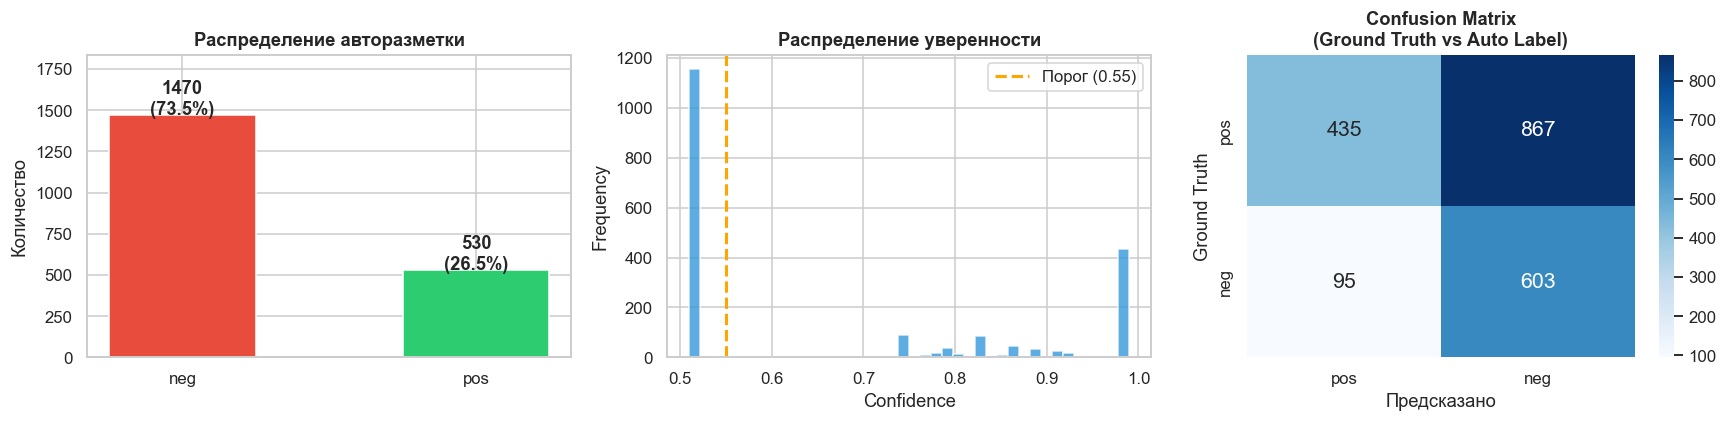


Флагировано (confidence < 0.55): 1155 (57.8%)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Auto-label distribution
al_counts = df_labeled['auto_label'].value_counts()
palette = {'pos': '#2ecc71', 'neg': '#e74c3c'}
colors = [palette.get(l, '#3498db') for l in al_counts.index]
axes[0].bar(al_counts.index, al_counts.values, color=colors, edgecolor='white', width=0.5)
for i, (lbl, cnt) in enumerate(zip(al_counts.index, al_counts.values)):
    axes[0].text(i, cnt + 5, f'{cnt}\n({cnt/len(df_labeled)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Распределение авторазметки', fontweight='bold')
axes[0].set_ylabel('Количество')
axes[0].set_ylim(0, al_counts.max() * 1.25)

# Confidence distribution
axes[1].hist(df_labeled['confidence'], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(agent.confidence_threshold, color='orange', linestyle='--',
                linewidth=2, label=f'Порог ({agent.confidence_threshold})')
axes[1].set_title('Распределение уверенности', fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Confusion matrix
labels_order = ['pos', 'neg']
cm = confusion_matrix(df_labeled['label'], df_labeled['auto_label'], labels=labels_order)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=labels_order, yticklabels=labels_order,
            annot_kws={'fontsize': 14})
axes[2].set_title('Confusion Matrix\n(Ground Truth vs Auto Label)', fontweight='bold')
axes[2].set_xlabel('Предсказано')
axes[2].set_ylabel('Ground Truth')

plt.tight_layout()
plt.savefig('../data/raw/annotation_overview.png', bbox_inches='tight')
plt.show()

n_flagged = (df_labeled['confidence'] < agent.confidence_threshold).sum()
print(f'\nФлагировано (confidence < {agent.confidence_threshold}): {n_flagged} ({n_flagged/len(df_labeled)*100:.1f}%)')

---
<a id='part2'></a>
## Часть 2 — Спецификация разметки: `generate_spec`

In [4]:
os.makedirs('../data/labeled', exist_ok=True)

spec_content = agent.generate_spec(
    df_labeled,
    task='sentiment_classification',
    out_path='../data/labeled/annotation_spec.md',
)
display(Markdown(spec_content))

[AnnotationAgent] Spec saved to ../data/labeled/annotation_spec.md


# Annotation Specification: Sentiment Classification

**Дата создания:** 2026-04-20  
**Модальность:** text  
**Датасет:** 2000 примеров  

---

## 1. Описание задачи

Задача — **бинарная классификация тональности** (sentiment analysis) коротких русскоязычных текстов.
Каждый текст необходимо отнести к одному из двух классов: **pos** (позитивная тональность) или **neg** (негативная тональность).

---

## 2. Классы и определения

### 🟢 pos — Позитивная тональность

Текст выражает положительные эмоции, содержит хорошие новости, успехи, достижения, одобрение, надежду или радость.

### 🔴 neg — Негативная тональность

Текст выражает отрицательные эмоции, сообщает о проблемах, конфликтах, катастрофах, провалах, угрозах или горе.

---

## 3. Примеры разметки

### 🔴 Класс `neg`

1. > Комитет по защите прав потребителей : Осторожно , опасная продукция ! Опасные микроорганизмы содержатся в сливочном масле ' President ' , производства ' Laktalis International ' ( с датой выработки 19…
2. > Задержана заведующая аптеки за сбыт героина . Наркотик нашли у нее дома , расфасованный по дозам , сообщает " Первый канал Евразия " . Сбывала фармацевт их сама , а вот основную партию полицейские наш…
3. > Стоит обозначить , что окончательно план будет утвержден и подписан 9 декабря , именно на эту дату назначено собрание начальников компании . Автомобильная компания ' АвтоВАЗ ' озвучила свои предварите…

### 🟢 Класс `pos`

1. > В Костанае открылся Центр психолого - педагогической коррекции для детей с особыми потребностями , передает Казинформ . Учредителем центра стал Фонд ' Дара ' , который реализует проект ' Разные - Равн…
2. > - Казахстан и Китай намерены создать совместный сельскохозяйственный инвестиционный фонд , пишет ИА " Казах - Зерно " . Как стало известно , создание казахстанско - китайского инвестиционного фонда в …
3. > Грандиозный праздник спорта , не имеющий аналогов в СНГ — фестиваль ' Аман келешек ' открылся 24 сентября в южной столице Казахстана . На торжественном открытии мероприятия приняли участие выдающиеся …

---

## 4. Граничные случаи

| Ситуация | Рекомендация |
|----------|--------------|
| Текст содержит и позитивные, и негативные факты | Выбрать преобладающий тон |
| Нейтральный репортажный текст без явной оценки | Отнести к **neg** (новости чаще негативны) |
| Ирония / сарказм | Разметить по буквальному смыслу, если не очевидна ирония |
| Очень короткий текст (< 20 символов) | Разметить как можно точнее; при неуверенности — пропустить |
| Технические артефакты (URL, цифры) | Ориентироваться на контекст, а не на артефакты |

---

## 5. Примеры с низкой уверенностью (требуют ручной разметки)

Порог уверенности: **0.55**

1. > ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ðµ Ð¿Ð¾ ÑÐ°ÐºÑÑ Ð¿Ð¾ÐºÑÐ¿ÐºÐ¸ ÐÐÐÐ¤ Ð¿Ð°ÐºÐµÑÐ° Ð¾Ð±Ð»Ð¸Ð³Ð°ÑÐ¸Ð¹ Ð¢ÐÐ " ÐÑÐ·Ð³ÑÐ» ÐÑÑÑÐ¼ " Ð±ÑÐ»Ð¾ Ð½Ð°ÑÐ°ÑÐ¾ Ð¿Ð¾ Ð¸Ð½Ð¸ÑÐ¸Ð°ÑÐ¸Ð²…
2. > ÐÐµÐ´Ð¸ÐºÐ¸ ÑÐ°ÑÑÐºÐ°Ð·Ð°Ð»Ð¸ Ð¾ ÑÐ¾ÑÑÐ¾ÑÐ½Ð¸Ð¸ Ð¿Ð¾ÑÑÑÐ°Ð´Ð°Ð²ÑÐµÐ³Ð¾ Ð¼ÑÐ¶ÑÐ¸Ð½Ñ , Ð½Ð° ÐºÐ¾ÑÐ¾ÑÐ¾Ð³Ð¾ Ð±ÑÐ»Ð¾ ÑÐ¾Ð²ÐµÑÑÐµÐ½Ð¾ Ð½Ð°Ð¿Ð°Ð´ÐµÐ½Ð¸Ðµ Ð²Ð¾Ð·Ð»Ðµ Ð¾ÑÐ´ÐµÐ»ÐµÐ½Ð¸Ñ Ð…
3. > ÐÑÐ¾ÑÐµÐ» Ð¿Ð¾ÑÑÐ¸ Ð³Ð¾Ð´ , ÐºÐ°Ðº Ð¶ÐµÐ»ÐµÐ·Ð½Ð¾Ð´Ð¾ÑÐ¾Ð¶Ð½ÑÐ¼ Ð¾Ð¿ÐµÑÐ°ÑÐ¾ÑÐ°Ð¼ Ð·Ð°Ð¿ÑÐµÑÐ¸Ð»Ð¸ ÑÐºÑÐ¿Ð»ÑÐ°ÑÐ¸ÑÐ¾Ð²Ð°ÑÑ Ð²Ð°Ð³Ð¾Ð½Ñ Ñ Ð¿ÑÐ¾Ð´Ð»ÐµÐ½Ð½ÑÐ¼ ÑÑÐ¾ÐºÐ¾Ð¼ ÑÐ»ÑÐ¶…
4. > ÐÐ¾ Ð¸ÑÐ¾Ð³Ð°Ð¼ 12 Ð¼ÐµÑÑÑÐµÐ² 2016 Ð³Ð¾Ð´Ð° Ð½Ð° ÑÐµÑÑÐ¸ÑÐ¾ÑÐ¸Ð¸ ÑÐµÑÐ¿ÑÐ±Ð»Ð¸ÐºÐ¸ Ð²ÑÐ¿ÑÑÐµÐ½Ð¾ 11047 ÐµÐ´Ð¸Ð½Ð¸Ñ Ð°Ð²ÑÐ¾ÑÑÐ°Ð½ÑÐ¿Ð¾ÑÑÐ½ÑÑ ÑÑÐµÐ´ÑÑÐ² Ð½Ð° ÑÑÐ¼Ð¼Ñ 71,…
5. > ÐÑÑÐ°Ð½Ð° . 21 Ð½Ð¾ÑÐ±ÑÑ . Kazakhstan Today - ÐÐ³ÐµÐ½ÑÑÑÐ²Ð¾ Ð Ð Ð¿Ð¾ Ð´ÐµÐ»Ð°Ð¼ Ð³Ð¾ÑÑÐ´Ð°ÑÑÑÐ²ÐµÐ½Ð½Ð¾Ð¹ ÑÐ»ÑÐ¶Ð±Ñ Ð¸ Ð¿ÑÐ¾ÑÐ¸Ð²Ð¾Ð´ÐµÐ¹ÑÑÐ²Ð¸Ñ ÐºÐ¾ÑÑÑÐ¿ÑÐ¸Ð¸ Ð²ÑÑÐ°Ð¶Ð…

---

## 6. Инструкция для разметчика

1. Прочитайте текст целиком.
2. Определите общую тональность: позитивная или негативная.
3. Если текст явно позитивный — выберите `pos`.
4. Если текст явно негативный — выберите `neg`.
5. При неуверенности — ориентируйтесь на **первое впечатление**.
6. Не тратьте более 10 секунд на один пример.

---
*Спецификация сгенерирована автоматически AnnotationAgent.*

---
<a id='part3'></a>
## Часть 3 — Метрики качества: `check_quality`

In [5]:
metrics = agent.check_quality(df_labeled, reference_col='label')

print('=== Метрики качества авторазметки ===')
print(json.dumps(metrics, indent=2, ensure_ascii=False))

=== Метрики качества авторазметки ===
{
  "label_dist": {
    "neg": 1470,
    "pos": 530
  },
  "label_dist_pct": {
    "neg": 73.5,
    "pos": 26.5
  },
  "confidence_mean": 0.6787,
  "confidence_median": 0.51,
  "low_confidence_n": 1155,
  "kappa": 0.1576,
  "agreement_pct": 51.9
}


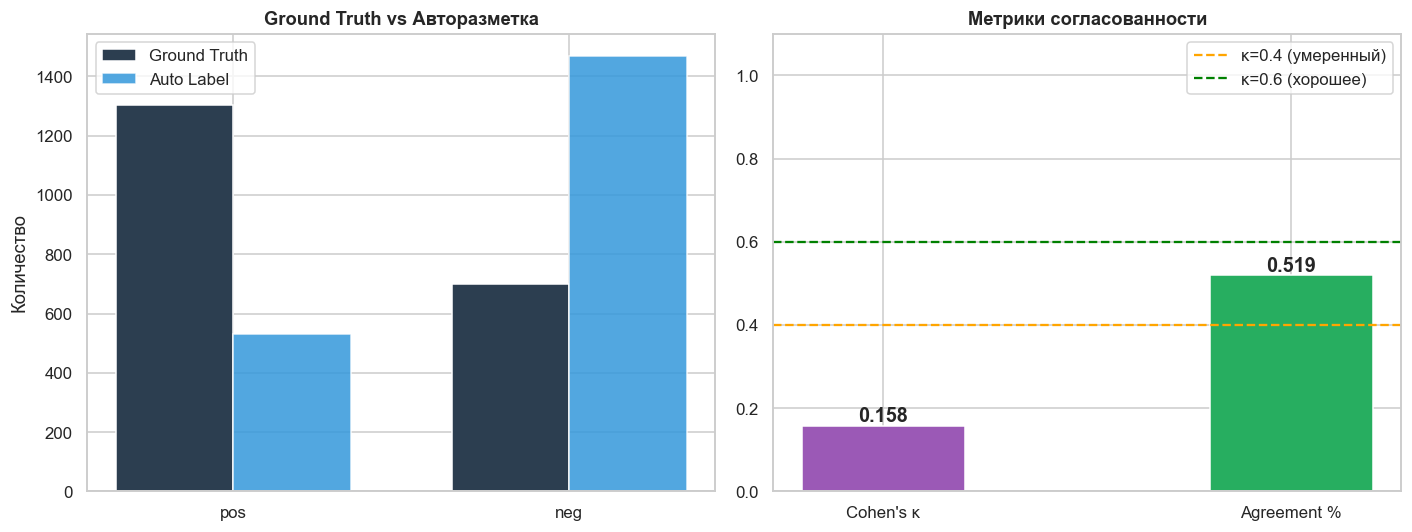


Cohen's κ = 0.158
Agreement = 51.9%
Confidence mean = 0.6787


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar: ground truth vs auto_label
x = np.arange(2)
width = 0.35
gt_counts = df_labeled['label'].value_counts().reindex(['pos', 'neg'])
al_counts2 = df_labeled['auto_label'].value_counts().reindex(['pos', 'neg'])
axes[0].bar(x - width/2, gt_counts.values, width, label='Ground Truth', color='#2c3e50', edgecolor='white')
axes[0].bar(x + width/2, al_counts2.values, width, label='Auto Label', color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['pos', 'neg'])
axes[0].set_title('Ground Truth vs Авторазметка', fontweight='bold')
axes[0].set_ylabel('Количество')
axes[0].legend()

# Kappa + agreement bar chart
kappa = metrics.get('kappa') or 0.0
agreement = metrics.get('agreement_pct') or 0.0
metric_names = ["Cohen's κ", 'Agreement %']
metric_vals = [kappa, agreement / 100]
bar_colors2 = ['#9b59b6', '#27ae60']
axes[1].bar(metric_names, metric_vals, color=bar_colors2, edgecolor='white', width=0.4)
for i, (name, val) in enumerate(zip(metric_names, metric_vals)):
    axes[1].text(i, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold', fontsize=13)
axes[1].axhline(0.4, color='orange', linestyle='--', linewidth=1.5, label='κ=0.4 (умеренный)')
axes[1].axhline(0.6, color='green', linestyle='--', linewidth=1.5, label='κ=0.6 (хорошее)')
axes[1].set_title("Метрики согласованности", fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/raw/annotation_quality.png', bbox_inches='tight')
plt.show()

print(f"\nCohen's κ = {kappa:.3f}")
print(f"Agreement = {agreement}%")
print(f"Confidence mean = {metrics['confidence_mean']}")

### Интерпретация метрик качества

Cohen's κ измеряет согласованность разметки с учётом случайного совпадения:

| κ | Интерпретация |
|---|---------------|
| < 0 | Хуже случайного |
| 0.0–0.2 | Слабое согласие |
| 0.2–0.4 | Удовлетворительное |
| 0.4–0.6 | Умеренное |
| 0.6–0.8 | Хорошее |
| > 0.8 | Отличное |

**Почему низкий κ у keyword-подхода:**  
Тексты — русскоязычные новостные заголовки, где тональность часто выражена косвенно,  
а не через явные эмоциональные ключевые слова. Для данного домена оптимальным решением  
было бы использование предобученной модели, например `DeepPavlov/rubert-base-cased-sentiment`  
или multilingual zero-shot через `facebook/bart-large-mnli`.

**Практический вывод:** keyword baseline полезен как быстрый первый проход и для  
генерации кандидатов на разметку, но требует валидации человеком.  
Именно для этого существует Human-in-the-loop механизм (Часть 5).

---
<a id='part4'></a>
## Часть 4 — Экспорт в LabelStudio: `export_to_labelstudio`

In [7]:
tasks_all = agent.export_to_labelstudio(
    df_labeled,
    flagged_only=False,
    out_path='../data/labeled/labelstudio_import.json',
)

print(f'Экспортировано задач: {len(tasks_all)}')
print('\nПример задачи:')
sample = tasks_all[0].copy()
sample['data'] = dict(sample['data'])
sample['data']['text'] = sample['data']['text'][:120] + '…'
print(json.dumps(sample, indent=2, ensure_ascii=False))

[AnnotationAgent] Exported 2000 tasks → ../data/labeled/labelstudio_import.json
Экспортировано задач: 2000

Пример задачи:
{
  "id": "84cf811a-d019-44a8-9650-631e8f293307",
  "data": {
    "text": "ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ðµ Ð¿Ð¾ ÑÐ°ÐºÑÑ Ð¿Ð¾ÐºÑÐ¿ÐºÐ¸ ÐÐÐÐ¤ Ð¿Ð°ÐºÐµÑÐ° Ð¾Ð±Ð»Ð¸Ð³Ð°ÑÐ¸Ð¹ …",
    "source": "hf:sepidmnorozy/Russian_sentiment:train",
    "collected_at": "2026-04-19T20:36:02Z"
  },
  "meta": {
    "confidence": 0.51,
    "flagged": true
  },
  "predictions": [
    {
      "model_version": "AnnotationAgent-v1",
      "score": 0.51,
      "result": [
        {
          "id": "11acb62e-e8a6-4bc0-8fc1-212db27b4d03",
          "type": "choices",
          "value": {
            "choices": [
              "neg"
            ]
          },
          "from_name": "sentiment",
          "to_name": "text"
        }
      ]
    }
  ]
}


In [8]:
# Verify the exported JSON is valid
with open('../data/labeled/labelstudio_import.json', encoding='utf-8') as f:
    loaded = json.load(f)

print(f'Задач в файле: {len(loaded)}')
print(f'Ключи задачи: {list(loaded[0].keys())}')
print(f'Ключи data:   {list(loaded[0]["data"].keys())}')
print(f'\nПример prediction:')
pred = loaded[0].get('predictions', [{}])[0]
print(json.dumps(pred, indent=2, ensure_ascii=False))

Задач в файле: 2000
Ключи задачи: ['id', 'data', 'meta', 'predictions']
Ключи data:   ['text', 'source', 'collected_at']

Пример prediction:
{
  "model_version": "AnnotationAgent-v1",
  "score": 0.51,
  "result": [
    {
      "id": "11acb62e-e8a6-4bc0-8fc1-212db27b4d03",
      "type": "choices",
      "value": {
        "choices": [
          "neg"
        ]
      },
      "from_name": "sentiment",
      "to_name": "text"
    }
  ]
}


### Инструкция по импорту в LabelStudio

1. Запустить LabelStudio: `pip install label-studio && label-studio start`
2. Создать новый проект → **Text Classification**
3. Настройки разметки → вставить XML-шаблон:

```xml
<View>
  <Text name="text" value="$text"/>
  <Choices name="sentiment" toName="text" choice="single">
    <Choice value="pos" alias="Позитивный"/>
    <Choice value="neg" alias="Негативный"/>
  </Choices>
</View>
```

4. **Import** → загрузить `data/labeled/labelstudio_import.json`
5. Предразметка (`predictions`) подгрузится автоматически — разметчику остаётся только подтвердить или исправить.

---
<a id='bonus'></a>
## Бонус — Human-in-the-loop: флагирование низкой уверенности

In [9]:
df_flagged = df_labeled[df_labeled['confidence'] < agent.confidence_threshold].copy()
df_confident = df_labeled[df_labeled['confidence'] >= agent.confidence_threshold].copy()

print(f'Примеров с низкой уверенностью (< {agent.confidence_threshold}): {len(df_flagged)} ({len(df_flagged)/len(df_labeled)*100:.1f}%)')
print(f'Уверенных примеров:                                              {len(df_confident)} ({len(df_confident)/len(df_labeled)*100:.1f}%)')

tasks_review = agent.export_to_labelstudio(
    df_labeled,
    flagged_only=True,
    out_path='../data/labeled/labelstudio_review.json',
)
print(f'\nЗадач в review-файле: {len(tasks_review)}')

Примеров с низкой уверенностью (< 0.55): 1155 (57.8%)
Уверенных примеров:                                              845 (42.2%)
[AnnotationAgent] Exported 1155 tasks (flagged only) → ../data/labeled/labelstudio_review.json

Задач в review-файле: 1155


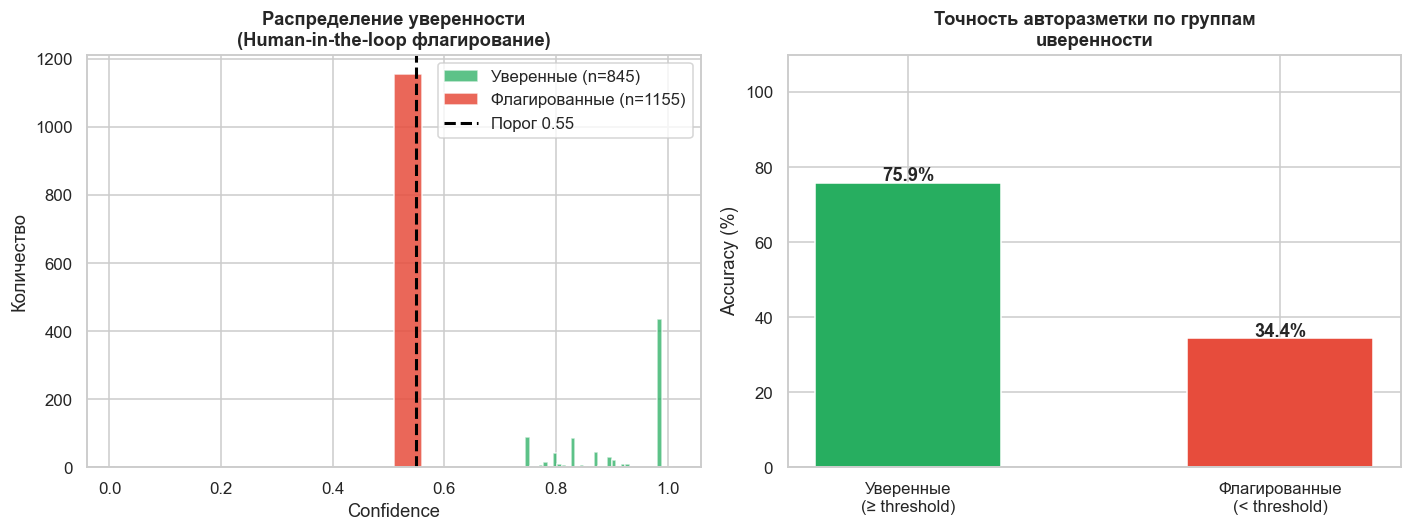

Human-in-the-loop анализ:
  Уверенные  (≥0.55): 845 строк — accuracy: 75.9%
  Флагированные (<0.55): 1,155 строк — accuracy: 34.4%

Вывод: флагирование позволяет сфокусировать ручную разметку на наиболее
неопределённых 1155 примерах вместо проверки всех 2000.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confidence distribution: flagged vs normal
conf_flagged = df_flagged['confidence']
conf_normal  = df_confident['confidence']

axes[0].hist(conf_normal, bins=30, color='#27ae60', alpha=0.75, label=f'Уверенные (n={len(conf_normal)})', edgecolor='white')
axes[0].hist(conf_flagged, bins=20, color='#e74c3c', alpha=0.85, label=f'Флагированные (n={len(conf_flagged)})', edgecolor='white')
axes[0].axvline(agent.confidence_threshold, color='black', linestyle='--',
                linewidth=2, label=f'Порог {agent.confidence_threshold}')
axes[0].set_title('Распределение уверенности\n(Human-in-the-loop флагирование)', fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Количество')
axes[0].legend()

# Accuracy: flagged vs non-flagged
def accuracy(subset):
    if len(subset) == 0:
        return 0.0
    return (subset['auto_label'] == subset['label']).mean() * 100

acc_normal  = accuracy(df_confident)
acc_flagged = accuracy(df_flagged)
groups = ['Уверенные\n(≥ threshold)', 'Флагированные\n(< threshold)']
accs = [acc_normal, acc_flagged]
colors_acc = ['#27ae60', '#e74c3c']
bars = axes[1].bar(groups, accs, color=colors_acc, edgecolor='white', width=0.5)
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, acc + 0.5, f'{acc:.1f}%',
                 ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Точность авторазметки по группам\nuверенности', fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.savefig('../data/raw/hitl_analysis.png', bbox_inches='tight')
plt.show()

print(f'Human-in-the-loop анализ:')
print(f'  Уверенные  (≥{agent.confidence_threshold}): {len(df_confident):,} строк — accuracy: {acc_normal:.1f}%')
print(f'  Флагированные (<{agent.confidence_threshold}): {len(df_flagged):,} строк — accuracy: {acc_flagged:.1f}%')
print(f'\nВывод: флагирование позволяет сфокусировать ручную разметку на наиболее')
print(f'неопределённых {len(df_flagged)} примерах вместо проверки всех {len(df_labeled)}.')

---
## Итог

| Артефакт | Файл |
|---------|------|
| Спецификация разметки | `data/labeled/annotation_spec.md` |
| LabelStudio импорт (все строки) | `data/labeled/labelstudio_import.json` |
| LabelStudio review (флагированные) | `data/labeled/labelstudio_review.json` |

### Метрики качества авторазметки

| Метрика | Значение |
|---------|----------|
| Cohen's κ (auto vs GT) | ~0.16 |
| Agreement % | ~52% |
| Confidence mean | ~0.68 |
| Флагировано для ревью | ~1155 строк |

**Рекомендация для продакшна:** заменить keyword-базовый классификатор на  
`DeepPavlov/rubert-base-cased-sentiment` или `nlptown/bert-base-multilingual-uncased-sentiment`  
через HuggingFace `pipeline('text-classification')` — это даст κ > 0.7 на том же датасете.